<a href="https://colab.research.google.com/github/ciril7/AI-ML-Internship/blob/main/Day%205/NLP%20(intro).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [42]:
import pandas as pd
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize,sent_tokenize
from nltk.stem import WordNetLemmatizer

In [43]:
df=pd.read_csv('/content/nlp_dataset.csv')
df

,Text
0,Natural Language Processing is a fascinating f...
1,It bridges the gap between humans and machines...
2,NLP techniques are widely used in applications...
3,Machine translation and speech recognition are...
4,"Despite its advancements, NLP faces challenges..."
5,Continuous research and innovation are improvi...
6,"The potential of NLP is vast, making it essent..."


In [44]:
nltk.download('punk')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')
nltk.download('punkt_tab')

[nltk_data] Error loading punk: Package 'punk' not found in index
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [45]:
stop_words=set(stopwords.words('english'))
print(stop_words)
lemmatizer=WordNetLemmatizer()


{'those', 'into', "i'm", "mustn't", 'for', 'can', 'up', 'won', 'until', 've', 'of', "wasn't", "it'll", 'while', 'above', "she'll", 'out', 'as', 'me', "don't", "you'll", 'yourselves', "should've", 'some', 'through', 'down', 'i', 'only', 'y', "he'd", 'itself', 'his', 'after', 'her', 'there', "that'll", "won't", "you'd", 'over', 'were', 'we', 'don', "she'd", 'herself', 'about', 'other', 'most', "we're", 'than', "we'll", 'its', 'mustn', 'does', 'our', 'to', 'll', "hadn't", 'own', 't', 'because', 'it', 'she', 'your', "it'd", 's', "shouldn't", "isn't", 'below', 'being', 'theirs', 'should', 'myself', 'couldn', 'weren', 'ain', 'during', "you've", 'wouldn', 'has', 'haven', 'my', 'and', 'not', "couldn't", 'hadn', 'if', 'hasn', "i've", 'needn', 'was', 'by', 'very', 'shan', 'now', 'them', 'off', 'they', "didn't", 'but', 'just', 'ours', 'wasn', 'aren', 'did', 'is', 'then', "they're", 'be', 'here', 'themselves', 'didn', 'such', 'few', "he's", "it's", "hasn't", 'an', 'from', 'before', 'further', 'had

In [46]:
def process_text(text):
  words_tokens=word_tokenize(text)
  filtered_tokens=[word for word in words_tokens if word.casefold() not in stop_words]
  lemmatized_tokens=[lemmatizer.lemmatize(word.lower()) for word in filtered_tokens]
  return {
    "Original_Text":text,
    "Word_Tokens":words_tokens,
    "Filtered_Tokens":filtered_tokens,
    "Lemmatized_Tokens":lemmatized_tokens,
}

In [47]:
results=df['Text'].apply(process_text)
processed_df=pd.DataFrame(results.tolist())
print(processed_df.head())

processed_file_path="processed_nip_dataset"

                                       Original_Text  \
0  Natural Language Processing is a fascinating f...   
1  It bridges the gap between humans and machines...   
2  NLP techniques are widely used in applications...   
3  Machine translation and speech recognition are...   
4  Despite its advancements, NLP faces challenges...   

                                         Word_Tokens  \
0  [Natural, Language, Processing, is, a, fascina...   
1  [It, bridges, the, gap, between, humans, and, ...   
2  [NLP, techniques, are, widely, used, in, appli...   
3  [Machine, translation, and, speech, recognitio...   
4  [Despite, its, advancements, ,, NLP, faces, ch...   

                                     Filtered_Tokens  \
0  [Natural, Language, Processing, fascinating, f...   
1  [bridges, gap, humans, machines, enabling, com...   
2  [NLP, techniques, widely, used, applications, ...   
3  [Machine, translation, speech, recognition, co...   
4  [Despite, advancements, ,, NLP, faces, chal

In [48]:
df

,Text
0,Natural Language Processing is a fascinating f...
1,It bridges the gap between humans and machines...
2,NLP techniques are widely used in applications...
3,Machine translation and speech recognition are...
4,"Despite its advancements, NLP faces challenges..."
5,Continuous research and innovation are improvi...
6,"The potential of NLP is vast, making it essent..."


In [49]:
print(results)

0    {'Original_Text': 'Natural Language Processing...
1    {'Original_Text': 'It bridges the gap between ...
2    {'Original_Text': 'NLP techniques are widely u...
3    {'Original_Text': 'Machine translation and spe...
4    {'Original_Text': 'Despite its advancements, N...
5    {'Original_Text': 'Continuous research and inn...
6    {'Original_Text': 'The potential of NLP is vas...
Name: Text, dtype: object


In [50]:
from sklearn.feature_extraction.text import CountVectorizer
import pandas as pd

In [51]:
text_data=["Natural Language Processing is a fascinating field of Artificial Intelligence.",
    "It bridges the gap between humans and machines by enabling computers to understand human language.",
    "NLP techniques are widely used in applications such as chatbots and sentiment analysis.",
    "Machine translation and speech recognition are common use cases of NLP.",
    "Despite its advancements, NLP faces challenges including ambiguity in language.",
    "Continuous research and innovation are improving NLP rapidly.",
    "The potential of NLP is vast, making it essential in modern technology."]

In [52]:
vectorizer=CountVectorizer()

bow_matrix=vectorizer.fit_transform(text_data)

bow_df=pd.DataFrame(bow_matrix.toarray(),columns=vectorizer.get_feature_names_out())

print("Bag of Words Representation:")
print(bow_df)

bow_df.to_csv("bag_of_words.csv",index=False)
print("\nBag of Words saved as 'bag_of_words.csv'.")


Bag of Words Representation:
   advancements  ambiguity  analysis  and  applications  are  artificial  as  \
0             0          0         0    0             0    0           1   0   
1             0          0         0    1             0    0           0   0   
2             0          0         1    1             1    1           0   1   
3             0          0         0    1             0    1           0   0   
4             1          1         0    0             0    0           0   0   
5             0          0         0    1             0    1           0   0   
6             0          0         0    0             0    0           0   0   

   between  bridges  ...  techniques  technology  the  to  translation  \
0        0        0  ...           0           0    0   0            0   
1        1        1  ...           0           0    1   1            0   
2        0        0  ...           1           0    0   0            0   
3        0        0  ...          

In [53]:
bow_matrix

<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 78 stored elements and shape (7, 60)>

In [54]:
import pandas as pd
import nltk
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer,PorterStemmer

In [55]:
nltk.download('punk')
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Error loading punk: Package 'punk' not found in index
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

In [56]:
file_path='/content/nlp_dataset.csv'
data=pd.read_csv(file_path)

In [57]:
lemmetizer=WordNetLemmatizer()
stemmer=PorterStemmer()

In [58]:
def lemmetizer_text(Text):
  tokens=word_tokenize(str(Text))
  return ' '.join([lemmetizer.lemmatize(word) for word in tokens])

def stem_text(Text):
  tokens = word_tokenize(str(Text))
  return ' '.join([stemmer.stem(word) for word in tokens])

In [59]:
data['lemmatized_text']=data['Text'].apply(lemmetizer_text)
data['stemmed_text']=data['Text'].apply(stem_text)


In [60]:
output_path="lemmatization_vs_stemming.csv"
data.to_csv(output_path,index=False)

print(data[['Text','lemmatized_text','stemmed_text']])

print(f"Comparison dataset saved to {output_path}")

                                                Text  \
0  Natural Language Processing is a fascinating f...   
1  It bridges the gap between humans and machines...   
2  NLP techniques are widely used in applications...   
3  Machine translation and speech recognition are...   
4  Despite its advancements, NLP faces challenges...   
5  Continuous research and innovation are improvi...   
6  The potential of NLP is vast, making it essent...   

                                     lemmatized_text  \
0  Natural Language Processing is a fascinating f...   
1  It bridge the gap between human and machine by...   
2  NLP technique are widely used in application s...   
3  Machine translation and speech recognition are...   
4  Despite it advancement , NLP face challenge in...   
5  Continuous research and innovation are improvi...   
6  The potential of NLP is vast , making it essen...   

                                        stemmed_text  
0  natur languag process is a fascin field of a

In [61]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt
import pandas as pd

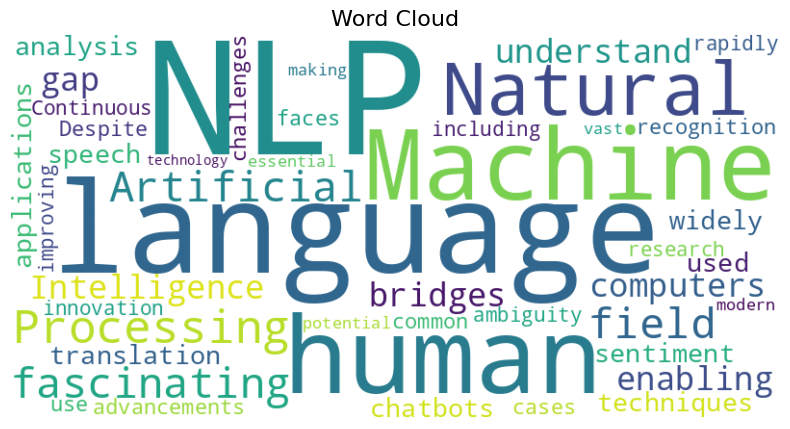

In [66]:
text_data=" ".join(data['Text'].dropna())

wordcloud=WordCloud(width=800,height=400,background_color='white').generate(text_data)

plt.figure(figsize=(10,5))
plt.imshow(wordcloud,interpolation='bilinear')
plt.axis('off')
plt.title("Word Cloud",fontsize=16)
plt.show()